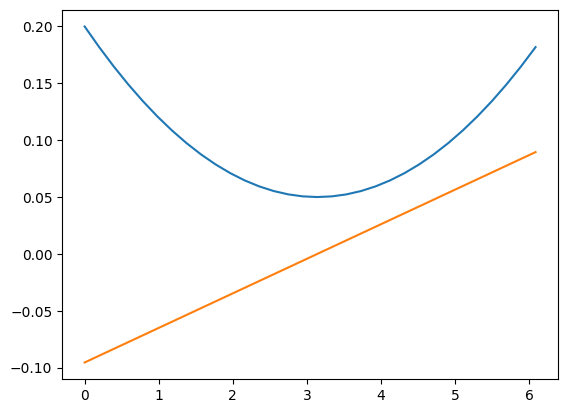

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5
N = 2**n_qubits
L = 2 * np.pi               
t = 10     
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.05
c_H = 0.2
c = 4*(c_H -c_L)/L**2 *x**2 - 4*(c_H -c_L)/L *x + c_H
cx = 8*(c_H - c_L)/L**2 *x - 4*(c_H -c_L)/L 


plt.plot(x, c, label='c(x)')
plt.plot(x, cx, label='c\'(x)')

In [20]:
# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

J :51.70513261926857
J_int :32
R :9.970936176846164, h :0.31159175552644264, gamma :2.838211852783846
Success Probability: 3.3976e-01


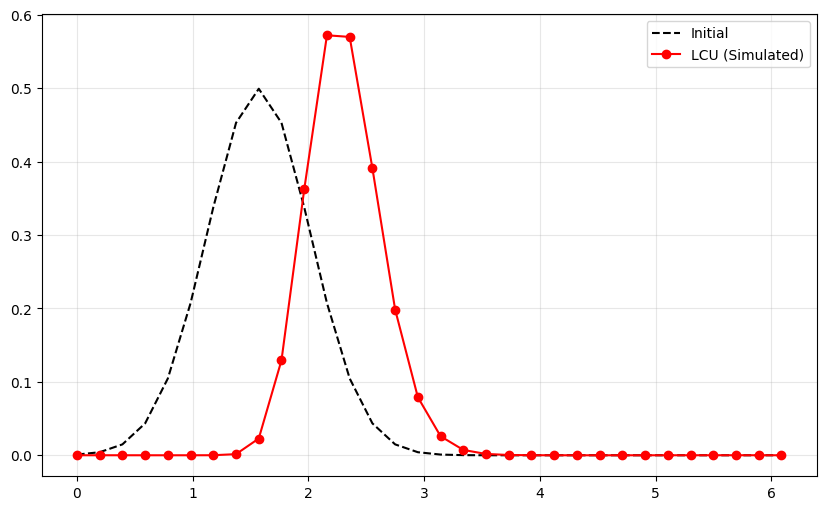

In [59]:
      
final_time = t
eps_lchs = 1e-3
eps_quad = 1e-3
c_lchs = 1

H_herm = cx/2

j_indices = np.arange(N)
k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
P_1 = 1j * (2 * np.pi / L) * (k_indices)
qft, qft_inv = get_qft_mat(n_qubits)
Delta = qft_inv @ np.diag(P_1) @ qft 

H_skew = Delta @ np.diag(c) + np.diag(c) @ Delta

norm = t * np.max(cx)/2 
h = np.pi / (norm/2 + np.log(64*np.exp(3*c_lchs/2)/(15*eps_quad)))
gamma = 1/c_lchs * np.sqrt(c_lchs+np.log((1+1/(2*np.pi))/eps_lchs))
R = 2*c_lchs*gamma**2
J = R/h
print(f"J :{J}")

J_int = int(2**(np.floor(np.log2(J)))) # closest power of 2 <= J
print(f"J_int :{J_int}")

R = J_int * h

print(f"R :{R}, h :{h}, gamma :{gamma}")
J = J_int
num_terms = 2*J_int
n_ancilla = np.log2(num_terms).astype(int)


k = h*np.linspace(-J, J, num_terms)

weights = (h / np.sqrt(2*np.pi)) * np.exp(c_lchs*(1-1j*k)) * np.exp(-(k**2+1)/(4*gamma**2)) / (1 + k**2)

magnitudes = np.abs(weights)
phases = np.angle(weights)

coeffs = np.sqrt(magnitudes)
coeffs = coeffs / np.linalg.norm(coeffs)         

reg_a = QuantumRegister(n_ancilla, 'ancilla') 
reg_s = QuantumRegister(n_qubits, 'system')
lc_qc = QuantumCircuit(reg_a, reg_s)

prep_gate = StatePreparation(coeffs)
lc_qc.append(prep_gate, reg_a)



for i in range(num_terms):
    U_diag = np.exp(1j * phases[i]) * np.exp(-1j * final_time * H_herm * k[i])
    ctrl_str = format(i, f'0{n_ancilla}b') 
    gate = DiagonalGate(U_diag).control(n_ancilla, ctrl_state=ctrl_str)
    lc_qc.append(gate, list(reg_a) + list(reg_s))


lc_qc.append(prep_gate.inverse(), reg_a)
U_unitary = expm(-1* final_time / 2 * H_skew)
lc_qc.append(UnitaryGate(U_unitary), reg_s)

circuit = QuantumCircuit(n_ancilla + n_qubits)

sigma = L/20
state = np.exp(-0.25*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)
stateprep = StatePreparation(state)
circuit.append(stateprep, range(n_ancilla, n_ancilla + n_qubits))

circuit.compose(lc_qc, inplace=True)

final_state = Statevector(circuit)
full_data = np.array(final_state)

system_state = full_data[0::2**n_ancilla]

success_prob = np.linalg.norm(system_state)**2
final = system_state / np.linalg.norm(system_state)

print(f"Success Probability: {success_prob:.4e}")

plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
plt.plot(x, np.abs(final), 'ro-', label=f'LCU (Simulated)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

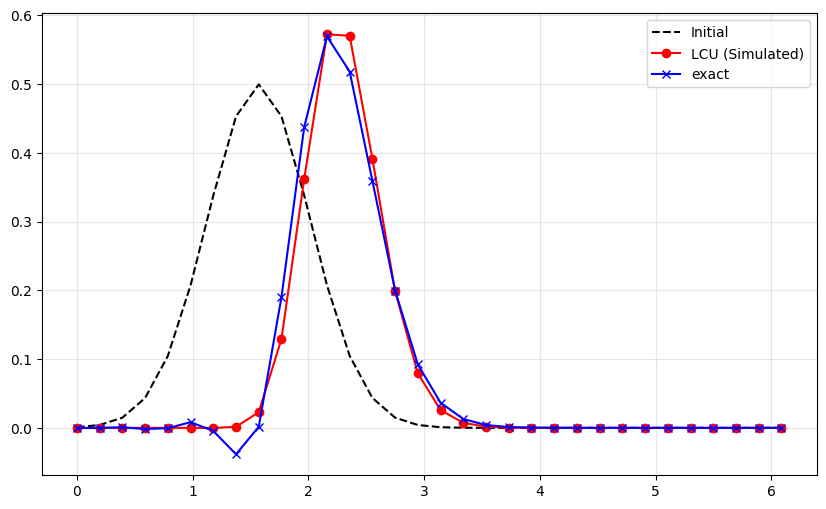

In [60]:

gamma_s = 1.0 / (2 * dx)


c_left = np.roll(c, 1)    # index i contains c_{i-1}
c_right = np.roll(c, -1)  # index i contains c_{i+1}

val_lower = gamma_s * c_left
val_upper = -gamma_s * c_right


M = np.diag(val_lower[1:], k=-1) + np.diag(val_upper[:-1], k=1)
M[0, N-1] = val_lower[0]
M[N-1, 0] = val_upper[N-1]
u_final = expm(M * t) @ state




plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
plt.plot(x, np.real(final), 'ro-', label=f'LCU (Simulated)')
plt.plot(x, u_final/np.linalg.norm(u_final), 'bx-', label=f'exact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()